# Exercises week 35

**FYS-STK3155/4155 — Applied Data Analysis and Machine Learning**

**August 24–30, 2026. Deadline: Friday August 28 at midnight.**

Reading for this set: the book, Chapter 3 (in particular Sections 3.1–3.7 from
week 34 and Sections 3.7–3.10 and 3.13 from this week), and the week 35 slides
(`week35slides.pdf`, `week35tuesday.pdf`). The Tuesday session and its notebook
(`week35tuesday.ipynb`) walk through most of the code you need here. For
exercise 1 the book by Faisal, Ong and Deisenroth, *Mathematics for Machine
Learning*, chapter 5 (sections 5.3–5.5) at https://mml-book.github.io/ is very
useful.
# Made by Carl Petter Duedahl, and

## 

## Exercise 1: Analytical exercises

In this exercise we derive the expressions for various derivatives of products of
vectors and matrices. Such derivatives are central to the optimization of various
cost functions. Although we will often use automatic differentiation in actual
calculations, having the analytical expressions is extremely helpful in case we
have simpler derivatives, as well as when we analyze various properties (like
second derivatives) of the chosen cost functions. Vectors are always written as
boldfaced lower-case letters and matrices as upper-case boldfaced letters.
Note that throughout we use the numerator (Jacobian) layout, in which the derivative of a
*scalar* with respect to a vector is a **row** vector — consistent with the example
$\partial(\boldsymbol{A}\boldsymbol{x})/\partial\boldsymbol{x}=\boldsymbol{A}$ in the hint below and with Faisal et al.; if you prefer the
column-gradient convention you will obtain the equivalent transposed results, e.g.
$(\boldsymbol{A}+\boldsymbol{A}^T)\boldsymbol{a}$ instead of $\boldsymbol{a}^T(\boldsymbol{A}+\boldsymbol{A}^T)$.

Show that

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{a}^T,
$$

and

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{A}\boldsymbol{a})}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\left(\boldsymbol{A}+\boldsymbol{A}^T\right),
$$

and

$$
\frac{\partial \left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x}-\boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A},
$$

and finally find the second derivative of this function with respect to the vector
$\boldsymbol{s}$.

If we replace the vector $\boldsymbol{s}$ with the unknown parameters
$\boldsymbol{\theta}$ used to define the ordinary least squares method, we end up
with the equations that determine these parameters. The matrix $\boldsymbol{A}$ is
then the design matrix $\boldsymbol{X}$, and $\boldsymbol{x}$ has to be replaced
with the outputs $\boldsymbol{y}$. The second derivative of the mean squared error
is then proportional to the Hessian matrix
$\boldsymbol{H}=\boldsymbol{X}^T\boldsymbol{X}$.

**Hint:** it is always useful to write out with summation indices the various
quantities; take a look at the examples in the week 35 slides. As an example,
consider the function

$$
f(\boldsymbol{x}) = \boldsymbol{A}\boldsymbol{x},
$$

which reads for a specific component $f_i$ (defining $\boldsymbol{A}$ to be an
$n\times n$ matrix and $\boldsymbol{x}$ a vector of length $n$)

$$
f_i = \sum_{j=0}^{n-1} a_{ij} x_j,
$$

which leads to

$$
\frac{\partial f_i}{\partial x_j} = a_{ij},
$$

and written out in terms of the vector $\boldsymbol{x}$ we have

$$
\frac{\partial f(\boldsymbol{x})}{\partial \boldsymbol{x}} = \boldsymbol{A}.
$$

### Solution:

For convenience, we write $y = \boldsymbol{a}^T\boldsymbol{x}$. (Note: $y$ is a scalar.) We may expand $y$ as

$$
y = \sum_{i} a_i x_i.
$$

It follows that

$$
\frac{\partial y}{\partial x_j} = \sum_{i} a_i \frac{\partial x_i}{x_j} = \sum_{i} a_i \delta_{ij} = a_j.
$$

Hence,

$$
\frac{\partial (\boldsymbol{a}^T\boldsymbol{x})}{\partial \boldsymbol{x}} = [a_0, a_1, \dots] = \boldsymbol{a}^T.
$$

Again, write $y = \boldsymbol{a}^T \boldsymbol{A} \boldsymbol{a}$. Written in component form, we get

$$
y = \sum_{i,j} A_{ij} a_i a_j.
$$

This gives

$$
\frac{\partial y}{\partial a_k} = \sum_{i,j} A_{ij} \frac{\partial (a_i a_j)}{a_k} = \sum_{i,j} A_{ij} (a_j \delta_{ik} + a_i \delta_{jk}) = \sum_j A_{kj} a_j + \sum_i A_{ik} a_i
$$

The first sum, we recognise as $(\boldsymbol{A}\boldsymbol{a})_k = (\boldsymbol{a}^T\boldsymbol{A}^T)_k$ (as we expect the Jacobian of a scalar to be be a row vector, we pick the second expression). The second sum, we recogise as $(\boldsymbol{a}^T\boldsymbol{A})_k = (\boldsymbol{A}^T\boldsymbol{a})_k$ (we similarly pick the first expression). Thus,

$$
\frac{\partial \boldsymbol{a}^T \boldsymbol{A} \boldsymbol{a}}{\partial \boldsymbol{a}} = \boldsymbol{a}^T\boldsymbol{A} + \boldsymbol{a}^T\boldsymbol{A}^T = \boldsymbol{a}^T(\boldsymbol{A} + \boldsymbol{A}^T)
$$

One last time, write $y = \left(\boldsymbol{x} - \boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x} - \boldsymbol{A}\boldsymbol{s}\right) = \boldsymbol{z}^T\boldsymbol{z}$, where $\boldsymbol{z} = \boldsymbol{x} - \boldsymbol{A}\boldsymbol{s}$. In component form, this is

$$
z_i = x_i - A_{ij}s_j,
$$

which yields

$$
y = \sum_i z_i^2 = \sum_i (x_i - A_{ij}s_j)^2
$$

By the chain rule, we thus have

$$
\frac{\partial y}{\partial s_k} = \sum_i \frac{\partial}{\partial s_k} \left((x_i - A_{ij}s_j)^2\right) = 2(x_i - A_{ij}s_j) \frac{\partial}{\partial s_k}(x_i - A_{ij}s_j) = -2(x_i - A_{ij}s_j)A_{ij}\delta_{jk} = -2(x_i - A_{ik}s_k)A_{ik},
$$

which leads to

$$
\frac{\partial \left(\boldsymbol{x} - \boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x} - \boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}} = -2\left(\boldsymbol{x} - \boldsymbol{A}\boldsymbol{s}\right)^T\boldsymbol{A}.
$$

To find an expression for the second derivative, we take the derivative (in component form) with respect to $s_l$:

$$
\frac{\partial^2 y}{\partial s_k \partial s_l} = -2\frac{\partial}{\partial s_l}(x_i - A_{ik}s_k)A_{ik} = 2A_{ik} A_{ik} \delta_{kl} = 2A_{il} A_{ik},
$$

which we recognise as

$$
\frac{\partial^2 \left(\boldsymbol{x} - \boldsymbol{A}\boldsymbol{s}\right)^T\left(\boldsymbol{x} - \boldsymbol{A}\boldsymbol{s}\right)}{\partial \boldsymbol{s}^2}
$$

## Exercise 2: Making your own data and exploring scikit-learn

We will generate our own dataset for a function $y(x)$ where $x\in[0,1]$ and
defined by random numbers computed with the uniform distribution. The function $y$
is a quadratic polynomial in $x$ with added stochastic noise according to the
normal distribution $\mathcal{N}(0,1)$. The following simple Python instructions
define our $x$ and $y$ values (with 100 data points).

In [1]:
import numpy as np
N=100
rng = np.random.default_rng(2026)
x = rng.random((100, 1))
y = 2.0 + 5.0 * x * x + 0.1 * rng.standard_normal((100, 1))

1. Write your own code (following the examples in the book, Chapter 3, and the
   week 34–35 slides) for computing the parametrization of the data set, fitting a
   second-order polynomial. That is, set up the design matrix
   $\boldsymbol{X}$ with columns $1, x, x^2$ and find the optimal parameters
   $\boldsymbol{\theta}$ from the normal equations (or, better, through the SVD —
   see the week 34 discussion of why we never invert
   $\boldsymbol{X}^T\boldsymbol{X}$).

2. Use thereafter **scikit-learn** (see the examples in the week 35 slides and the
   Tuesday notebook) and compare with your own code. Note that scikit-learn does
   not, by default, include the intercept in the design matrix. See the
   discussions on scaling your data in the week 35 slides (and Section 3.13 of the
   book). This type of problem appears in particular if we fit a polynomial with
   an intercept.

3. Using scikit-learn, compute also the mean squared error, a risk metric
   corresponding to the expected value of the squared (quadratic) error

$$
MSE(\boldsymbol{y},\tilde{\boldsymbol{y}}) = \frac{1}{n}\sum_{i=0}^{n-1}\left(y_i-\tilde{y}_i\right)^2,
$$

   and the $R^2$ score function. If $\tilde{y}_i$ is the predicted value of the
   $i$-th sample and $y_i$ is the corresponding true value, then the $R^2$ score is

$$
R^2(\boldsymbol{y},\tilde{\boldsymbol{y}}) = 1 - \frac{\sum_{i=0}^{n-1}(y_i-\tilde{y}_i)^2}{\sum_{i=0}^{n-1}(y_i-\bar{y})^2},
$$

   where the mean value of $\boldsymbol{y}$ is

$$
\bar{y} = \frac{1}{n}\sum_{i=0}^{n-1} y_i.
$$

   You can use the functionality included in scikit-learn, or your own functions
   from the Tuesday notebook. Discuss the meaning of these results. Try also to
   vary the coefficient in front of the added stochastic noise term and discuss
   the quality of the fits.

In [2]:
# Your code for exercise 2 here

# Own code:
X = np.vander(x.flatten(), 3, increasing=True) # Feature matrix X

def ols(X, y):
    """OLS through SVD"""
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ (U.T @ y / s)

theta_own = ols(X, y.flatten()) # using our own code

# scikit-learn:

from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X,y)

theta_skl = np.zeros(3)
theta_skl[0] = linreg.intercept_[0]
theta_skl[1:] = linreg.coef_[:,1:]

theta_diff = np.abs(theta_own - theta_skl)

print("The difference in theta between our own code and scikit-learn is (for each component):", theta_diff)

The difference in theta between our own code and scikit-learn is (for each component): [0.00000000e+00 9.92261828e-16 1.77635684e-15]


The difference in $\theta$ between using our own code and using scikit-learn is minimal.

In [3]:
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error, mean_absolute_error
#print(X)
ypredict = linreg.predict(X)
y_ordered = y[X[:,1].argsort()] # order the y-values based on x-values (x is not ordered)
#print(ypredict)
ypr_ord=ypredict[X[:,1].argsort()]
#print(y_ordered)
#print(y)
# Calculate mean squared error:
print("Mean Squared Error: ", mean_squared_error(y_ordered, ypr_ord))
# Calculate variance score (R squared):
print("Rsquare:", r2_score(y_ordered, ypr_ord))

Mean Squared Error:  0.01372815674626301
Rsquare: 0.9928732429893427


As the mean squared error is small and $R^2$ is close to $1$, the 2nd degree polynomial fit is a good fit. Increasing the value coefficient in front of the stochastic noise term increases the mean squared error and decreases $R^2$. The opposite is the case when this coefficient is decreased. This is expected, as added noise increases the uncertainty of the prediction.

## Exercise 3: Split data in test and training data

In this exercise we want you to compute the MSE for the training data and the test
data as a function of the complexity of a polynomial, that is the degree of a given
polynomial.

The aim is to reproduce Figure 2.11 of Hastie et al., *The Elements of Statistical
Learning*. Feel free to read the discussions leading to that figure.

Our data is defined by $x\in[-3,3]$ with a total of, for example, $n=100$ data
points. You should try to vary the number of data points $n$ in your analysis.

In [4]:
n = 100
rng = np.random.default_rng(2026)
x = np.linspace(-3, 3, n).reshape(-1, 1)
y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + rng.normal(0, 0.1, x.shape)

where $y$ is the function we want to fit with a given polynomial.

1. Write a first code which sets up a design matrix $\boldsymbol{X}$ defined by a
   fifth-order polynomial and split your data set into training and test data
   (`sklearn.model_selection.train_test_split` is fine).

2. Write thereafter (using either scikit-learn or your matrix inversion/SVD code)
   an ordinary least squares fit and compute the mean squared error for the
   training data and the test data. These calculations should apply to a model
   given by a fifth-order polynomial. If you compare your own code with
   scikit-learn, note that the latter does not include the intercept by default —
   see the discussions on scaling in the week 35 slides.

3. Add now a model which allows you to make polynomials up to degree $15$. Perform
   a standard OLS fit of the training data and compute the MSE for the training
   and test data and plot both as functions of the polynomial degree. Compare what
   you see with Figure 2.11 of Hastie et al. Comment on your results. For which
   polynomial degree do you find the optimal (smallest) test MSE?

training MSE:  0.027593291702804553
Test MSE:  0.04584659593881837
Own theta:
[[ 0.90456364]
 [ 0.15307931]
 [-0.0701829 ]
 [ 0.09970177]
 [ 0.00170716]
 [-0.01311895]]

Sklearn:
[[ 0.          0.15307931 -0.0701829   0.09970177  0.00170716 -0.01311895]]
[0.90456364]


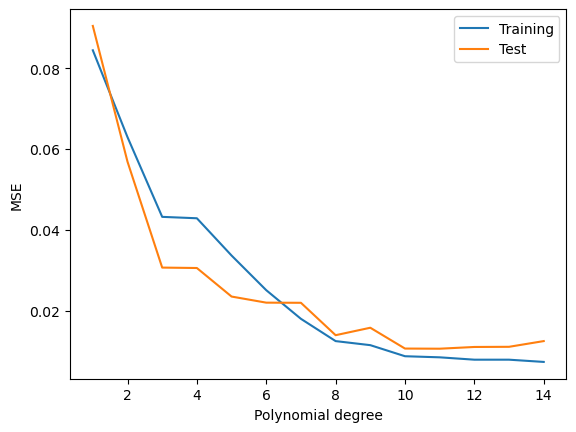

Best degree: 11
Minimum test MSE: 0.010584607384987255


In [5]:
# Your code for exercise 3 here
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

X = np.vander(x.flatten(), 6, increasing=True)

Xtr, Xte, ytr, yte = train_test_split(X,y, test_size=0.3)
linreg=LinearRegression()
linreg.fit(Xtr,ytr)
y_te_pr=linreg.predict(Xte)
y_tr_pr=linreg.predict(Xtr)


theta = np.linalg.lstsq(Xtr, ytr, rcond=None)[0]

y_tr_pr = Xtr @ theta
y_te_pe = Xte @ theta

mse_tr = mean_squared_error(ytr, y_tr_pr)
mse_te = mean_squared_error(yte, y_te_pr)

print("training MSE: ", mse_tr)
print("Test MSE: ", mse_te)

linreg = LinearRegression()
linreg.fit(Xtr, ytr)

y_tr_pr_sklearn = linreg.predict(Xtr)
y_te_pr_sklearn = linreg.predict(Xte)

print("Own theta:")
print(theta)

print("\nSklearn:")
print(linreg.coef_)
print(linreg.intercept_)



Xdata = x.flatten()

xtr, xte, ytr, yte = train_test_split(
    Xdata, y, test_size=0.3, random_state=50
)

degrees = range(1, 15)

mse_tr = []
mse_te = []

for degree in degrees:

    Xtr = np.vander(xtr, degree + 1, increasing=True)
    Xte = np.vander(xte, degree + 1, increasing=True)

    theta = np.linalg.lstsq(Xtr, ytr, rcond=None)[0]

    y_tr_pr = Xtr @ theta
    y_te_pr = Xte @ theta

    mse_tr.append(mean_squared_error(ytr, y_tr_pr))
    mse_te.append(mean_squared_error(yte, y_te_pr))

plt.plot(degrees, mse_tr, label="Training")
plt.plot(degrees, mse_te, label="Test")

plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

best_degree = degrees[np.argmin(mse_te)]

print("Best degree:", best_degree)
print("Minimum test MSE:", min(mse_te))

Compared to Figure 2.11 of Hastie et al., the test curve does not curve upwards for higher order polynomials. Perhaps running the code for even higher degrees fixes this.

We find the optimal test MSE for a degree 11 polynomial. With more data points, the optimal degree will increase.

Do we increase the polynoms further we see that the test error is increasing more after 15 as seen below:

training MSE:  0.03040134275578596
Test MSE:  0.0298273026850001
Own theta:
[[ 0.88496334]
 [ 0.24072762]
 [-0.03981575]
 [ 0.06708632]
 [-0.0023577 ]
 [-0.0101145 ]]

Sklearn:
[[ 0.          0.24072762 -0.03981575  0.06708632 -0.0023577  -0.0101145 ]]
[0.88496334]


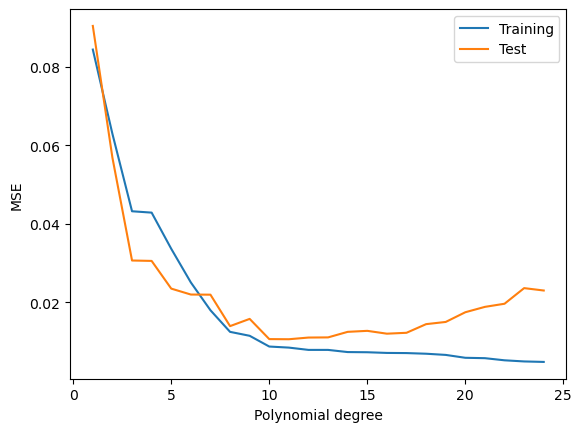

Best degree: 11
Minimum test MSE: 0.010584607384987255


In [6]:
# Your code for exercise 3 here
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

X = np.vander(x.flatten(), 6, increasing=True)

Xtr, Xte, ytr, yte = train_test_split(X,y, test_size=0.3)
linreg=LinearRegression()
linreg.fit(Xtr,ytr)
y_te_pr=linreg.predict(Xte)
y_tr_pr=linreg.predict(Xtr)


theta = np.linalg.lstsq(Xtr, ytr, rcond=None)[0]

y_tr_pr = Xtr @ theta
y_te_pe = Xte @ theta

mse_tr = mean_squared_error(ytr, y_tr_pr)
mse_te = mean_squared_error(yte, y_te_pr)

print("training MSE: ", mse_tr)
print("Test MSE: ", mse_te)

linreg = LinearRegression()
linreg.fit(Xtr, ytr)

y_tr_pr_sklearn = linreg.predict(Xtr)
y_te_pr_sklearn = linreg.predict(Xte)

print("Own theta:")
print(theta)

print("\nSklearn:")
print(linreg.coef_)
print(linreg.intercept_)



Xdata = x.flatten()

xtr, xte, ytr, yte = train_test_split(
    Xdata, y, test_size=0.3, random_state=50
)

degrees = range(1, 25)

mse_tr = []
mse_te = []

for degree in degrees:

    Xtr = np.vander(xtr, degree + 1, increasing=True)
    Xte = np.vander(xte, degree + 1, increasing=True)

    theta = np.linalg.lstsq(Xtr, ytr, rcond=None)[0]

    y_tr_pr = Xtr @ theta
    y_te_pr = Xte @ theta

    mse_tr.append(mean_squared_error(ytr, y_tr_pr))
    mse_te.append(mean_squared_error(yte, y_te_pr))

plt.plot(degrees, mse_tr, label="Training")
plt.plot(degrees, mse_te, label="Test")

plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.legend()
plt.show()

best_degree = degrees[np.argmin(mse_te)]

print("Best degree:", best_degree)
print("Minimum test MSE:", min(mse_te))

## Exercise 4 (optional): a first taste of Ridge

This voluntary exercise connects directly to Monday's lecture and to Case 4 of the
Tuesday notebook; it is also a useful warm-up for Project 1.

Keep the data set and the degree-15 design matrix from exercise 3, standardise the
feature columns (training statistics only!), and replace OLS by Ridge regression,

$$
\hat{\boldsymbol{\theta}}_{\mathrm{Ridge}} = \left(\boldsymbol{X}^T\boldsymbol{X}+\lambda\boldsymbol{I}\right)^{-1}\boldsymbol{X}^T\boldsymbol{y}.
$$

1. Plot the training and test MSE as functions of $\lambda$ on a logarithmic grid,
   say $\lambda\in[10^{-8},10^{4}]$. Do you find the U-shape discussed in the
   lecture?

2. Compare your best test MSE with the best value found in exercise 3 by varying
   the polynomial degree. Two dials, one phenomenon — which gives the finer
   control?

3. Check explicitly that your training MSE is monotonically increasing in
   $\lambda$, and explain in one sentence why it must be.

In [7]:
# Your code for exercise 4 here
